[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/cdg-ime/blob/main/Mineração.ipynb)

# Ciência de Dados Geoespaciais - Mineração

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Realizar análise exploratória em dados numéricos e categóricos;
2. Realizar análise exploratória em dados geoespaciais;
3. Selecionar modelos mais adequados à solução.

## O Contexto

Com os dados **prospectados** e **pré-processados**, chegamos à etapa de **mineração** — extrair conhecimento e padrões a partir dos dados.

Prospecção $\rightarrow$ Pré-Processamento $\rightarrow$ **Exploração** $\rightarrow$ Modelagem $\rightarrow$ Comunicação 

<img src="media/imgs/mineração.png">



## 1. Realizar análise exploratória em dados numéricos e categóricos

A **Análise Exploratória de Dados (EDA)** precede qualquer modelagem. Seu objetivo é *entender* os dados antes de *explicá-los*. Em ciência de dados geoespaciais, a EDA tem uma dimensão extra: além das estatísticas clássicas, investigamos **onde** os padrões ocorrem.

**Dataset de referência**: [Extração dos dados da plataforma IBGE cidades](https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030) em combinação com malha de referência do IBGE

In [37]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, r2_score,
                              classification_report, confusion_matrix)

np.random.seed(42)
sns.set_theme(style='whitegrid')

url_cidades = 'https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030'
api_base = 'https://servicodados.ibge.gov.br/api/v1'
indicadores = {
    96385: 'populacao',
    96386: 'dens_demografica_ibge',
    329756: 'idhm',
    78192: 'ideb_anos_finais_publica',
    143558: 'salario_medio_mensal_sm',
    60030: 'esgotamento_sanitario_pct',
}

def valor_mais_recente(serie):
    """Retorna o valor numérico mais recente de uma série anual da API do IBGE."""
    for ano, valor in sorted(serie.items(), key=lambda item: item[0], reverse=True):
        if valor not in (None, '-', '...'):
            return pd.to_numeric(valor, errors='coerce'), int(ano)
    return np.nan, np.nan

def baixar_indicador(indicador_id, nome_coluna):
    endpoint = f'{api_base}/pesquisas/indicadores/{indicador_id}/resultados/N6[N3[33]]'
    resposta = requests.get(endpoint, timeout=30)
    resposta.raise_for_status()
    registros = []
    for item in resposta.json()[0]['res']:
        valor, ano = valor_mais_recente(item['res'])
        registros.append({
            'cod_mun6': str(item['localidade']).zfill(6),
            nome_coluna: valor,
            f'{nome_coluna}_ano': ano,
        })
    return pd.DataFrame(registros)

def baixar_populacao_historica():
    endpoint = f'{api_base}/pesquisas/indicadores/96385/resultados/N6[N3[33]]'
    resposta = requests.get(endpoint, timeout=30)
    resposta.raise_for_status()
    registros = []
    for item in resposta.json()[0]['res']:
        serie = item['res']
        registros.append({
            'cod_mun6': str(item['localidade']).zfill(6),
            'pop_2010': pd.to_numeric(serie.get('2010'), errors='coerce'),
            'pop_2022': pd.to_numeric(serie.get('2022'), errors='coerce'),
        })
    return pd.DataFrame(registros)

def limpar_colunas_ano(gdf):
    """Incorpora colunas *_ano ao nome da variável correspondente e remove o *_ano."""
    renomear = {}
    remover = []
    aliases_analise = {}

    for coluna_ano in sorted(col for col in gdf.columns if col.endswith('_ano')):
        coluna_base = coluna_ano[:-4]
        if coluna_base not in gdf.columns:
            continue

        anos = sorted(gdf[coluna_ano].dropna().astype(int).unique())
        if len(anos) == 1:
            sufixo = str(anos[0])
        elif len(anos) > 1:
            sufixo = str(anos[-1])
            print(f'Aviso: {coluna_ano} possui múltiplos anos {anos}; usando sufixo {sufixo}.')
        else:
            sufixo = 'sem_ano'

        nova_coluna = f'{coluna_base}_{sufixo}'
        renomear[coluna_base] = nova_coluna
        remover.append(coluna_ano)
        aliases_analise[nova_coluna] = coluna_base

    return gdf.rename(columns=renomear).drop(columns=remover), aliases_analise

filename = "cidades_rj.gpkg"
if not os.path.exists(filename):

    dados_ibge = None
    for indicador_id, nome_coluna in indicadores.items():
        parcial = baixar_indicador(indicador_id, nome_coluna)
        dados_ibge = parcial if dados_ibge is None else dados_ibge.merge(parcial, on='cod_mun6', how='outer')
    del dados_ibge['populacao']; del dados_ibge['populacao_ano']

    malha_path = 'BR_Municipios_2022.zip'
    if not os.path.exists(malha_path):
        malha_url = (
            'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/'
            'malhas_municipais/municipio_2022/Brasil/BR/BR_Municipios_2022.zip'
        )

        with requests.get(malha_url, stream=True) as resposta:
            resposta.raise_for_status()
            with open(malha_path, "wb") as f:
                for bloco in resposta.iter_content(chunk_size=8192):
                    f.write(bloco)

    malha = gpd.read_file(malha_path)
    malha_rj = malha.query("SIGLA_UF == 'RJ'").copy()
    malha_rj['cod_mun6'] = malha_rj['CD_MUN'].astype(str).str[:6]
    del malha_rj['CD_MUN']; del malha_rj['SIGLA_UF']

    gdf = malha_rj.merge(dados_ibge, on='cod_mun6', how='left')
    gdf = gdf.merge(baixar_populacao_historica(), on='cod_mun6', how='left')
    gdf = gdf.rename(columns={'NM_MUN': 'municipio', 'AREA_KM2': 'area_km2'})
    gdf = gdf.to_crs('EPSG:4326')

    # Variáveis derivadas a partir dos dados oficiais.
    gdf['cresc_pop_pct'] = ((gdf['pop_2022'] / gdf['pop_2010'] - 1) * 100).round(2)
    gdf['classe_dev'] = pd.cut(
        gdf['idhm'],
        bins=[0, 0.699, 0.799, 1.0],
        labels=['Médio', 'Alto', 'Muito Alto']
    )
    gdf['classe_ideb'] = pd.cut(
        gdf['ideb_anos_finais_publica'],
            bins=[0, 3.0, 4.0, 5.0, 6.0, 10.0],
            labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto']
        )

    # Limpar anos e renomer colunas dos anos
    gdf, aliases_analise = limpar_colunas_ano(gdf)

    gdf.to_file(filename, driver="GPKG")
else:
    gdf = gpd.read_file(filename)


print(f'Fonte IBGE Cidades: {url_cidades}')
print(f'Shape gdf limpo: {gdf.shape}')
gdf.head()

Fonte IBGE Cidades: https://cidades.ibge.gov.br/brasil/sintese/rj?indicadores=96385,96386,329756,78192,143558,60030
Shape gdf limpo: (92, 14)


,municipio,area_km2,cod_mun6,dens_demografica_ibge_2022,idhm_2010,ideb_anos_finais_publica_2023,salario_medio_mensal_sm_2023,esgotamento_sanitario_pct_2022,pop_2010,pop_2022,dist_capital_km,cresc_pop_pct,classe_dev,geometry
0,Angra dos Reis,813.420,330010,205.84,0.724,4.4,3.2,69.95,169511,167434,92.7,-1.23,Alto,"MULTIPOLYGON (((-44.51649 -23.03589, -44.51633..."
1,Aperibé,94.542,330015,116.71,0.692,5.3,1.8,84.82,10213,11034,195.5,8.04,Médio,"MULTIPOLYGON (((-42.11437 -21.61204, -42.11394..."
2,Araruama,638.276,330020,203.16,0.718,4.3,1.6,32.34,112008,129671,120.3,15.77,Alto,"MULTIPOLYGON (((-42.28399 -22.93928, -42.28444..."
3,Areal,110.724,330022,106.82,0.684,4.1,2.5,41.54,11423,11828,83.4,3.55,Médio,"MULTIPOLYGON (((-43.09004 -22.23844, -43.09135..."
4,Armação dos Búzios,70.977,330023,563.65,0.728,4.0,1.9,30.79,27560,40006,155.0,45.16,Alto,"MULTIPOLYGON (((-41.91872 -22.77162, -41.91854..."


### **1.1 Síntese numérica**

#### **1.1.1 Estatísticas descritivas**

In [38]:
est = gdf.describe().T
# Extra: relative standard deviation
est['rsd%'] = 100* est['std'] / est['mean']
est.round(2)

,count,mean,std,min,25%,50%,75%,max,rsd%
area_km2,92.0,475.55,488.22,19.39,215.62,373.61,586.25,4032.49,102.66
dens_demografica_ibge_2022,92.0,682.04,1797.64,12.62,51.89,109.48,311.11,12521.64,263.57
idhm_2010,92.0,0.71,0.04,0.61,0.68,0.71,0.73,0.84,5.19
ideb_anos_finais_publica_2023,92.0,4.50,0.55,3.50,4.07,4.40,4.90,5.80,12.32
salario_medio_mensal_sm_2023,92.0,2.12,0.65,1.20,1.80,1.90,2.20,5.70,30.90
esgotamento_sanitario_pct_2022,92.0,67.49,20.33,2.86,56.04,70.59,82.74,98.71,30.12
pop_2010,92.0,173803.58,672081.03,5269.00,17502.25,34878.50,113948.25,6320446.00,386.69
pop_2022,92.0,174512.76,658952.50,5415.00,17476.75,37767.00,132384.00,6211223.00,377.60
dist_capital_km,92.0,123.59,75.49,0.00,64.08,109.10,170.23,291.50,61.09
cresc_pop_pct,92.0,5.09,11.25,-12.87,-0.77,1.84,7.76,54.77,220.88


#### **1.1.2 Matriz Variância Covariância (MVC)**

A MVC resume a variabilidade conjunta das variáveis numéricas. Na diagonal principal ficam as **variâncias**, isto é, o quanto cada variável varia em relação à sua própria média. Fora da diagonal ficam as **covariâncias**, que indicam se duas variáveis tendem a variar no mesmo sentido ou em sentidos opostos.

Para duas variáveis $X$ e $Y$, a covariância amostral é:

$$\operatorname{cov}(X,Y)=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})$$

- Valores **positivos** indicam que, quando uma variável aumenta, a outra tende a aumentar.
- Valores **negativos** indicam que, quando uma variável aumenta, a outra tende a diminuir.
- Valores próximos de **zero** sugerem pouca variação linear conjunta.

#### **1.1.2 Matriz Variância Covariância (MVC)**

In [39]:
cols_numericas = gdf.describe().columns.tolist()

mvc = gdf[cols_numericas].cov()
mvc.round(4)

,area_km2,dens_demografica_ibge_2022,idhm_2010,ideb_anos_finais_publica_2023,salario_medio_mensal_sm_2023,esgotamento_sanitario_pct_2022,pop_2010,pop_2022,dist_capital_km,cresc_pop_pct
area_km2,2.383572e+05,-1.514761e+05,0.8593,-20.7239,59.8310,-9.422869e+02,6.215142e+07,6.241792e+07,9.606464e+03,-269.8865
dens_demografica_ibge_2022,-1.514761e+05,3.231504e+06,17.6960,-308.2689,-67.4033,1.379864e+04,4.645542e+08,4.515983e+08,-5.761323e+04,-3298.5615
idhm_2010,8.593000e-01,1.769600e+01,0.0014,-0.0004,0.0057,3.210000e-01,8.145889e+03,8.101317e+03,-8.576000e-01,0.0801
ideb_anos_finais_publica_2023,-2.072390e+01,-3.082689e+02,-0.0004,0.3077,0.0042,4.600000e-02,4.123744e+03,4.862817e+03,1.403650e+01,0.5758
salario_medio_mensal_sm_2023,5.983100e+01,-6.740330e+01,0.0057,0.0042,0.4278,-2.732000e-01,1.240196e+05,1.246371e+05,2.157000e+00,1.8807
esgotamento_sanitario_pct_2022,-9.422869e+02,1.379864e+04,0.3210,0.0460,-0.2732,4.131508e+02,2.997160e+06,2.875090e+06,-4.083215e+02,-80.6233
pop_2010,6.215142e+07,4.645542e+08,8145.8890,4123.7438,124019.6476,2.997160e+06,4.516929e+11,4.427459e+11,-1.326235e+07,-823015.0497
pop_2022,6.241792e+07,4.515983e+08,8101.3174,4862.8170,124637.0853,2.875090e+06,4.427459e+11,4.342184e+11,-1.289549e+07,-688892.2755
dist_capital_km,9.606464e+03,-5.761323e+04,-0.8576,14.0365,2.1570,-4.083215e+02,-1.326235e+07,-1.289549e+07,5.699219e+03,90.5141
cresc_pop_pct,-2.698865e+02,-3.298561e+03,0.0801,0.5758,1.8807,-8.062330e+01,-8.230150e+05,-6.888923e+05,9.051410e+01,126.4788


#### **1.1.3 Principal Component Analisys (PCA)**

PCA é uma técnica estatística usada para reduzir a dimensionalidade de grandes conjuntos de dados, transformando variáveis possivelmente correlacionadas em um conjunto menor de variáveis não correlacionadas, chamadas componentes principais.

<img src="media/imgs/newplot.png">

In [40]:
import plotly.graph_objects as go
import numpy as np
n = 1000

# Semi-eixos do elipsoide
a = 50.0
c = 10.0

# Direções aleatórias
v = np.random.normal(size=(3, n))
v /= np.linalg.norm(v, axis=0)

# Raio com distribuição uniforme no volume
r = np.random.rand(n)**(1/3)

# Pontos na esfera unitária
sphere = v * r

# Transformação para elipsoide
ellipsoid = np.vstack([
    a * sphere[0],
    a * sphere[1],
    c * sphere[2]
])

# plotly
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=ellipsoid[0],
        y=ellipsoid[1],
        z=ellipsoid[2],
        mode='markers',
        marker=dict(
            size=3,
            opacity=0.7
        )
    )
)

fig.update_layout(
    title="Como resumir essa nuvem de pontos?",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'   # preserves proportions
    ),
    width=700,
    height=500
)

fig.show()

#### **1.1.3 Principal Component Analisys (PCA)**

A MVC serve de base para métodos como PCA, pois é útil para entender a dispersão conjunta.

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Dados no formato (amostras, variáveis)
X = ellipsoid.T  # (100, 3)

# 0) Centralizar os dados
centro = X.mean(axis=0)
Xc = X - centro

# 1) Matriz de variância-covariância (MVC)
MVC = np.cov(Xc, rowvar=False)
mvc_df = pd.DataFrame(MVC, columns=['X', 'Y', 'Z'], index=['X', 'Y', 'Z'])
print("1) Matriz de Variância-Covariância da nuvem de pontos:")
display(mvc_df)

# 2) Autovalores e autovetores da MVC
autovalores, autovetores = np.linalg.eigh(MVC)

# 2) Ordenar do maior para o menor autovalor
idx = np.argsort(autovalores)[::-1]

autovalores = autovalores[idx]
autovetores = autovetores[:, idx]

print("\n2) Autovalores (λ) da MVC:")
print(autovalores)

print("\n3) Variâncias explicadas (λi/soma(λ)):")
print(100*autovalores/sum(autovalores))

print("\n4) Autovetores da MVC:")
print(autovetores)

1) Matriz de Variância-Covariância da nuvem de pontos:


,X,Y,Z
X,490.548022,-27.909240,4.911000
Y,-27.909240,491.638339,-2.131435
Z,4.911000,-2.131435,19.875132



2) Autovalores (λ) da MVC:
[519.05704221 463.18775748  19.81669451]

3) Variâncias explicadas (λi/soma(λ)):
[51.79892105 46.2234863   1.97759266]

4) Autovetores da MVC:
[[-0.70038912  0.71368834 -0.01020003]
 [ 0.71369204  0.70044868  0.00391384]
 [-0.00993786  0.00453847  0.99994032]]


**Principal Component Analisys (PCA)**

<img src="media/imgs/newplot2.png">

In [42]:
scale = 2*np.sqrt(autovalores)

colors = ['red', 'green', 'blue']

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=ellipsoid[0],
        y=ellipsoid[1],
        z=ellipsoid[2],
        mode='markers',
        marker=dict(
            size=3,
            opacity=0.7
        ),
        name=f'Nuvem de pontos 3D'
    )
)

fig.update_layout(
    title="nuvem de pontos e suas 3 componentes principais",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'   # preserves proportions
    ),
    width=700,
    height=500
)
for i in range(3):
    v = autovetores[:, i] * scale[i]

    fig.add_trace(
        go.Scatter3d(
            x=[centro[0], centro[0]+v[0]],
            y=[centro[1], centro[1]+v[1]],
            z=[centro[2], centro[2]+v[2]],
            mode='lines',
            line=dict(
                width=8,
                color=colors[i]
            ),
            name=f'PC{i+1}'
        )
    )
fig.show()

#### **1.1.3 Principal Component Analisys (PCA)**

No entanto, a comparação direta entre pares de variáveis com unidades diferentes deve ser feita com cuidado pois a magnitude da covariância depende da escala das variáveis. Voltando ao dataset do Rio de Janeiro:

| Variável | Unidade | Variância |
| -------- | ------- | --------- |
| Area     | Km²     | 238357.19 |
| IDH      | 0 a 1   | 0.0014    |

In [43]:
# MVC padronizada e PCA
from sklearn.decomposition import PCA

cols_numericas = gdf.describe().columns.tolist()
dados_numericos = gdf[cols_numericas].dropna()

scaler = StandardScaler()
dados_padronizados = pd.DataFrame(
    scaler.fit_transform(dados_numericos),
    columns=cols_numericas,
    index=dados_numericos.index,
)

mvc_padronizada = dados_padronizados.cov()

pca = PCA()
componentes_pca = pca.fit_transform(dados_padronizados)

df_pca = pd.DataFrame(
    componentes_pca,
    columns=[f'PC{i}' for i in range(1, componentes_pca.shape[1] + 1)],
    index=dados_padronizados.index,
)

variancia_pca = pd.DataFrame({
    'componente': df_pca.columns,
    'autovalor': pca.explained_variance_,
    'variancia_explicada_pct': pca.explained_variance_ratio_ * 100,
    'variancia_acumulada_pct': np.cumsum(pca.explained_variance_ratio_) * 100,
})


#### **1.1.3 Principal Component Analisys (PCA)**

In [44]:
mvc_padronizada.round(2)

,area_km2,dens_demografica_ibge_2022,idhm_2010,ideb_anos_finais_publica_2023,salario_medio_mensal_sm_2023,esgotamento_sanitario_pct_2022,pop_2010,pop_2022,dist_capital_km,cresc_pop_pct
area_km2,1.01,-0.17,0.05,-0.08,0.19,-0.10,0.19,0.20,0.26,-0.05
dens_demografica_ibge_2022,-0.17,1.01,0.27,-0.31,-0.06,0.38,0.39,0.39,-0.43,-0.16
idhm_2010,0.05,0.27,1.01,-0.02,0.24,0.43,0.33,0.34,-0.31,0.20
ideb_anos_finais_publica_2023,-0.08,-0.31,-0.02,1.01,0.01,0.00,0.01,0.01,0.34,0.09
salario_medio_mensal_sm_2023,0.19,-0.06,0.24,0.01,1.01,-0.02,0.29,0.29,0.04,0.26
esgotamento_sanitario_pct_2022,-0.10,0.38,0.43,0.00,-0.02,1.01,0.22,0.22,-0.27,-0.36
pop_2010,0.19,0.39,0.33,0.01,0.29,0.22,1.01,1.01,-0.26,-0.11
pop_2022,0.20,0.39,0.34,0.01,0.29,0.22,1.01,1.01,-0.26,-0.09
dist_capital_km,0.26,-0.43,-0.31,0.34,0.04,-0.27,-0.26,-0.26,1.01,0.11
cresc_pop_pct,-0.05,-0.16,0.20,0.09,0.26,-0.36,-0.11,-0.09,0.11,1.01


#### **1.1.3 Principal Component Analisys (PCA)**

In [45]:
variancia_pca.round(2)

,componente,autovalor,variancia_explicada_pct,variancia_acumulada_pct
0,PC1,3.01,29.74,29.74
1,PC2,1.83,18.09,47.84
2,PC3,1.29,12.74,60.58
3,PC4,1.16,11.43,72.01
4,PC5,0.95,9.37,81.38
5,PC6,0.66,6.56,87.94
6,PC7,0.57,5.66,93.60
7,PC8,0.35,3.46,97.06
8,PC9,0.30,2.94,100.00
9,PC10,0.00,0.00,100.00


#### **1.1.3 Principal Component Analisys (PCA)**

In [46]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,0.558452,0.763576,0.061157,-0.377293,0.982504,1.190724,-0.517307,0.483572,-0.336694,-0.002495
1,-0.861719,-0.042418,-0.235099,1.867009,-0.364602,0.002722,0.549382,-0.199881,0.584345,-0.003825
2,-0.800668,0.477413,0.619988,-1.057872,-0.637856,-1.345589,-0.310250,-0.081433,-0.516825,0.007814
3,-0.665811,-0.216092,0.476847,-1.144793,-0.864447,0.929815,-0.485290,-0.081480,-0.451169,0.001311
4,-1.123071,1.004006,3.062161,-1.192627,-1.167319,-1.558791,0.782019,-0.864202,0.290205,-0.024036
...,...,...,...,...,...,...,...,...,...,...
87,0.204439,-0.681415,0.096589,0.320530,0.384138,-0.017641,-0.451714,-0.324887,-0.049704,0.003266
88,0.454827,0.010635,-0.823751,-0.409776,1.678916,-0.505055,-0.889345,0.404226,-0.245205,-0.003833
89,-1.634222,0.266328,-0.522687,-0.842640,-0.465627,0.523200,1.456133,-1.415553,0.190084,0.000453
90,0.124419,-0.471226,-0.031215,-0.315976,0.424408,0.338068,-0.834666,0.127770,-0.123966,0.000955


### **1.2 Síntese gráfica**

<img src="media/imgs/sitese_grafica.png">

#### **1.2.1 Histograma das variáveis numéricas**

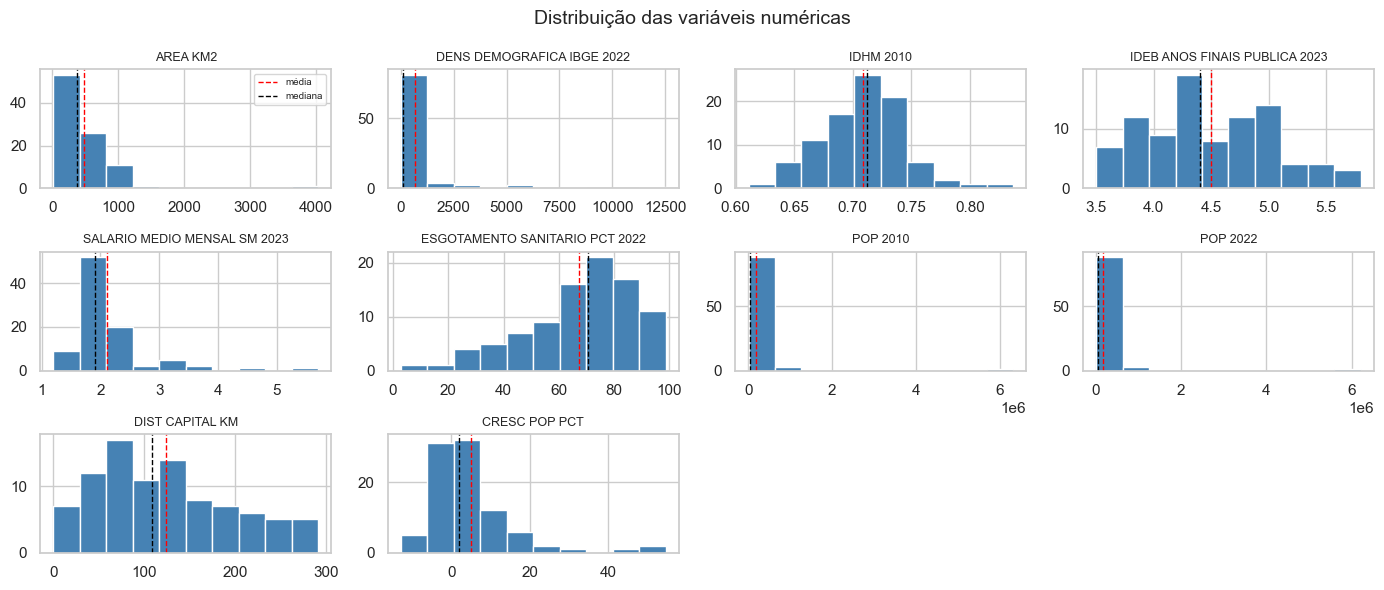

In [47]:
num_cols = gdf.describe().columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(gdf[col].dropna(), bins=10, edgecolor='white', color='steelblue')
    ax.set_title(col.upper().replace("_"," "), fontsize=9)
    ax.axvline(gdf[col].mean(),   color='red',    linestyle='--', linewidth=1, label='média')
    ax.axvline(gdf[col].median(), color='black', linestyle='--',  linewidth=1, label='mediana')

axes[0,0].legend(fontsize=7)
# Turn off the axes
axes[2,2].axis('off'); axes[2,3].axis('off')
plt.suptitle('Distribuição das variáveis numéricas', fontsize=14)
plt.tight_layout()
plt.show()

#### **1.2.2 Boxplot das variáveis numéricas**

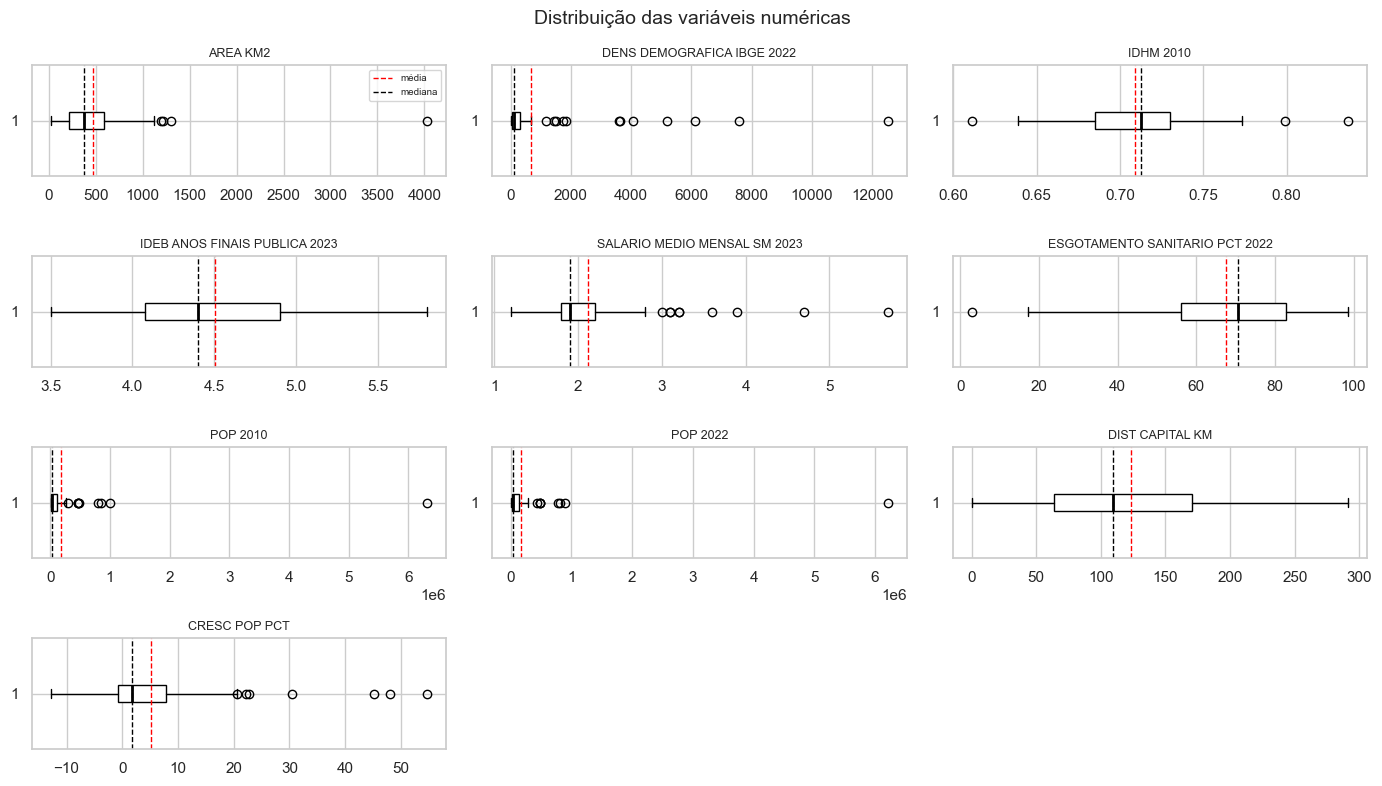

In [48]:
fig, axes = plt.subplots(4, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.boxplot(
        gdf[col],
        orientation = 'horizontal',
        patch_artist=True,
        showfliers=True,
        boxprops=dict(facecolor="white", edgecolor="black"),
        medianprops=dict(color="black", linewidth=2),
    )
    ax.set_title(col.upper().replace("_"," "), fontsize=9)
    ax.axvline(gdf[col].mean(),   color='red',    linestyle='--', linewidth=1, label='média')
    ax.axvline(gdf[col].median(), color='black', linestyle='--',  linewidth=1, label='mediana')
axes[0,0].legend(fontsize=7)
# Turn off the axes
axes[3,2].axis('off'); axes[3,1].axis('off')
plt.suptitle('Distribuição das variáveis numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### **1.3 Regras de associação entre variáveis numéricas**

#### **1.3.1 Relação entre duas variáveis numéricas - Pearson**

O **coeficiente de correlação de Pearson** ($r$) mede a força e a direção da <b style="color:#2ECC40">relação linear</b> entre duas variáveis contínuas:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i-\bar{x})^2 \cdot \sum (y_i-\bar{y})^2}} \quad \in [-1, 1]$$

A interpretação é:

- $r \approx 1$: forte correlação linear positiva;
- $r \approx -1$: forte correlação linear negativa;
- $r \approx 0$: ausência de correlação linear significativa.

> A correlação **não implica causalidade**. Sempre interprete no contexto do domí­nio.

#### **1.3.2 Matriz de correlação de Pearson**

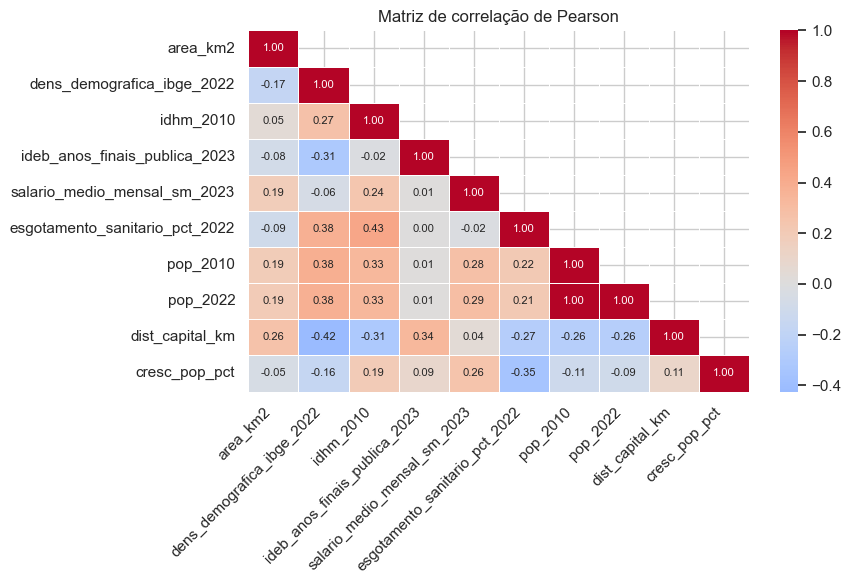

In [49]:
#  Mapa de calor de correlações
corr = gdf[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(corr.values, 1)  # Apenas triângulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de correlação de Pearson', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **1.3.3 Relação entre duas variáveis numéricas - Spearman**

O **coeficiente de correlação de Spearman** ($\rho$) Mede a  <b style="color:#2ECC40">relação monotônica</b> (se $X$ cresce, $Y$ cresce ou decresce, não necessariamente em linha reta). É calculada a partir dos **postos** (*ranks*) das observações, e não diretamente dos valores originais.

Quando não há empates nos postos, pode ser escrito como:

$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2 - 1)}$$

em que $d_i$ é a diferença entre os postos de cada par de observações e $n$ é o número de observações.

A interpretação também varia de $-1$ a $1$:

- $\rho \approx 1$: associação monotônica positiva forte;
- $\rho \approx -1$: associação monotônica negativa forte;
- $\rho \approx 0$: ausência de associação monotônica clara.

> Spearman é útil quando há outliers, escalas muito diferentes ou relações curvas, desde que a tendência geral seja monotônica.

#### **1.3.3 Relação entre duas variáveis numéricas - Spearman**

- Converte cada variável numérica em ranks;
- Calcula a correlação de Pearson sobre esses ranks

Exemplo de ranqueamento:

In [50]:
gdf['rank_dev'] = gdf['classe_dev'].map({ 'Muito Alto': 1,
                                          'Alto': 2,
                                          'Médio': 3,
                                          'Baixo': 4,
                                          'Muito Baixo': 5
                                        })
gdf['rank_ideb'] = gdf['classe_dev'].map({ 'Muito Alto': 1,
                                          'Alto': 2,
                                          'Médio': 3,
                                          'Baixo': 4,
                                          'Muito Baixo': 5
                                        })
gdf[['municipio','rank_dev', 'rank_ideb' ]]

,municipio,rank_dev,rank_ideb
0,Angra dos Reis,2,2
1,Aperibé,3,3
2,Araruama,2,2
3,Areal,3,3
4,Armação dos Búzios,2,2
...,...,...,...
87,Três Rios,2,2
88,Valença,2,2
89,Varre-Sai,3,3
90,Vassouras,2,2


#### **1.3.4 Matriz de correlação de Spearman**

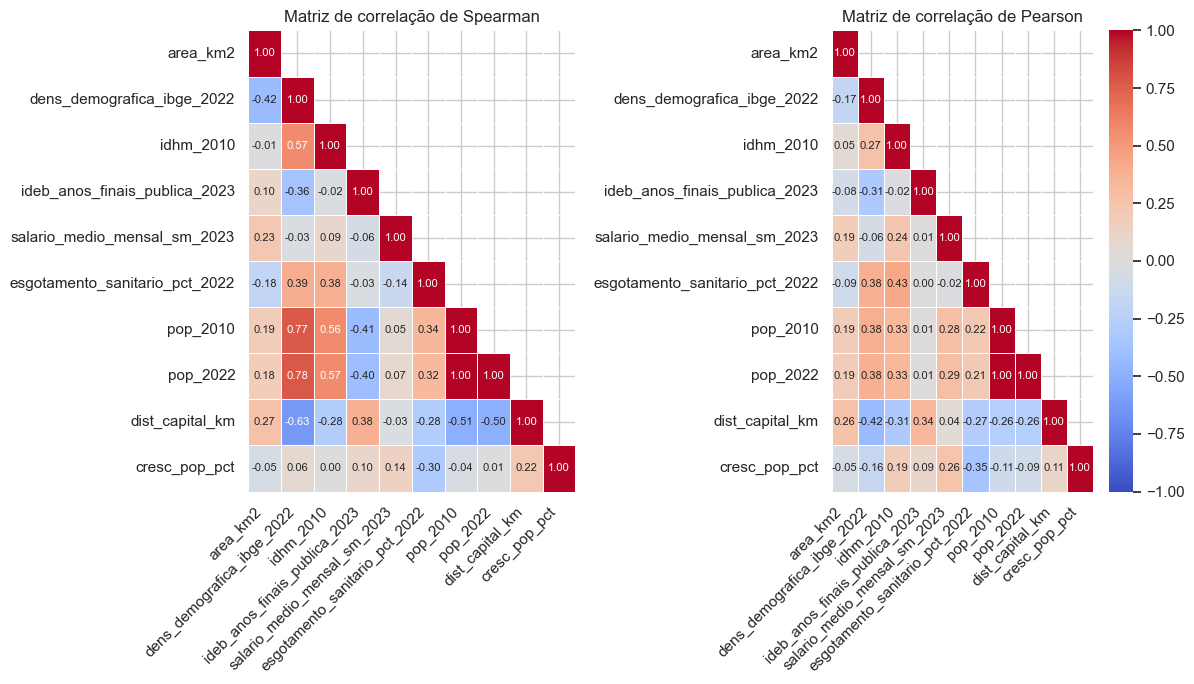

In [51]:
#  Mapa de calor de correlações
ranks = gdf[num_cols].rank()
corr = ranks.corr(method='pearson')
# ou 
# corr = gdf[num_cols].corr(method="spearman")

fig, ax = plt.subplots(1,2, figsize=(12, 7))
mask = np.triu(corr.values, 1)  # Apenas triângulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', cbar=False,
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax[0], annot_kws={'size': 8})
ax[0].set_title('Matriz de correlação de Spearman', fontsize=12)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')

sns.heatmap(gdf[num_cols].corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax[1], annot_kws={'size': 8})
ax[1].set_title('Matriz de correlação de Pearson', fontsize=12)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **1.3.5 Dispersão**

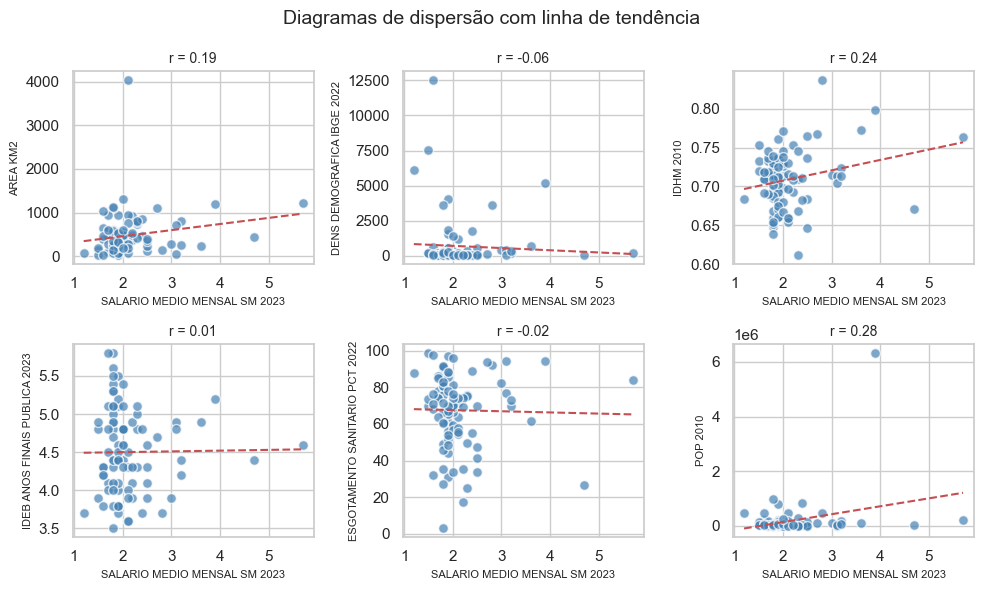

In [52]:
pares =  [('salario_medio_mensal_sm_2023', 'area_km2'),
            ('salario_medio_mensal_sm_2023', 'dens_demografica_ibge_2022'),
            ('salario_medio_mensal_sm_2023', 'idhm_2010'),
            ('salario_medio_mensal_sm_2023', 'ideb_anos_finais_publica_2023'),
            ('salario_medio_mensal_sm_2023', 'esgotamento_sanitario_pct_2022'),
            ('salario_medio_mensal_sm_2023', 'pop_2010'),
            ('salario_medio_mensal_sm_2023', 'pop_2022'),
            ('salario_medio_mensal_sm_2023', 'dist_capital_km'),
            ('salario_medio_mensal_sm_2023', 'cresc_pop_pct')]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
for ax, (x, y) in zip(axes.flat, pares):
    dados = gdf[[x, y]].dropna()
    ax.scatter(dados[x], dados[y], alpha=0.7, edgecolors='white', s=50, color='steelblue')
    # Linha de tendência
    m, b = np.polyfit(dados[x], dados[y], 1)
    xs = np.linspace(dados[x].min(), dados[x].max(), 100)
    ax.plot(xs, m*xs + b, 'r--', linewidth=1.5)
    r = dados[[x,y]].corr().iloc[0,1]
    ax.set_title(f'r = {r:.2f}', fontsize=10)
    ax.set_xlabel(x.upper().replace("_"," "), fontsize=8)
    ax.set_ylabel(y.upper().replace("_"," "), fontsize=8)
    # ax.set_title(col.upper().replace("_"," "), fontsize=9)

plt.suptitle('Diagramas de dispersão com linha de tendência', fontsize=14)
plt.tight_layout()
plt.show()

#### **1.3.6 Gráfico de bolhas (+1 grau de liberdade na representação gráfica)**

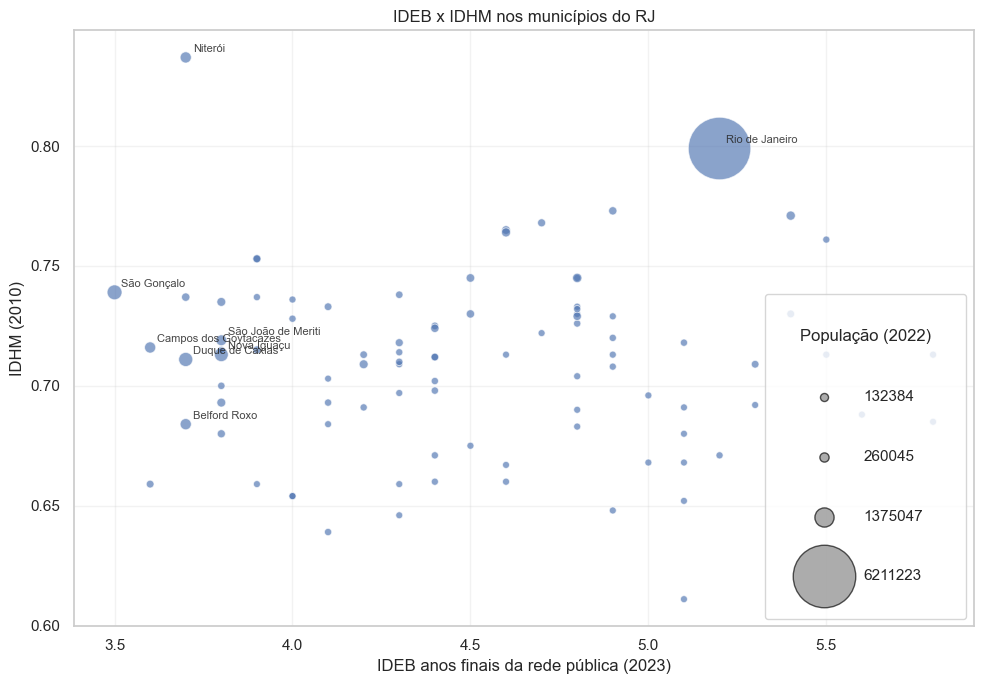

In [53]:
# Gráfico de bolhas: menor para maior bolha
x_col = 'ideb_anos_finais_publica_2023'
y_col = 'idhm_2010'
pop_col = 'pop_2022'

bolhas = (
    gdf[['municipio', x_col, y_col, pop_col]]
    .dropna(subset=[x_col, y_col, pop_col])
    .sort_values(pop_col, ascending=True)
    .copy()
)

# Em matplotlib, s representa área; elevamos o raio ao quadrado para que o raio codifique a população.
raio = np.interp(
    bolhas[pop_col],
    (bolhas[pop_col].min(), bolhas[pop_col].max()),
    (5, 45)
)
bolhas['area_bolha'] = raio ** 2

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    bolhas[x_col],
    bolhas[y_col],
    s=bolhas['area_bolha'],
    # c=bolhas[pop_col],
    # cmap='viridis',
    alpha=0.65,
    edgecolors='white',
    linewidth=0.7
)

for _, row in bolhas.tail(8).iterrows():
    ax.annotate(
        row['municipio'],
        xy=(row[x_col], row[y_col]),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.85
    )

# Values you want to show in the legend
legend_values = [gdf['pop_2022'].quantile(0.75), gdf['pop_2022'].quantile(0.9), 
                 gdf['pop_2022'].quantile(0.99), gdf['pop_2022'].max()]
legend_values = [str(int(i)) for i in legend_values]

# Compute the same radius used in the plot
legend_radius = np.interp(
    legend_values,
    (bolhas[pop_col].min(), bolhas[pop_col].max()),
    (5, 45)
)

# Create legend handles
handles = [
    plt.scatter(
        [], [],
        s=r**2,
        facecolor='gray',
        edgecolor='black',
        alpha=0.65
    )
    for r in legend_radius
]

ax.legend(handles, legend_values, title='População (2022)', 
          loc='lower right', frameon=True, labelspacing=3.0,
          borderpad=2.3, handletextpad=1.6)

# cbar = fig.colorbar(scatter, ax=ax, shrink=0.82)
# cbar.set_label('População (2022)')

ax.set_xlabel('IDEB anos finais da rede pública (2023)')
ax.set_ylabel('IDHM (2010)')
ax.set_title('IDEB x IDHM nos municípios do RJ')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

#### **1.3.7 Gráfico de bolhas e escala de cores (+2 graus de liberdade na representação gráfica)**

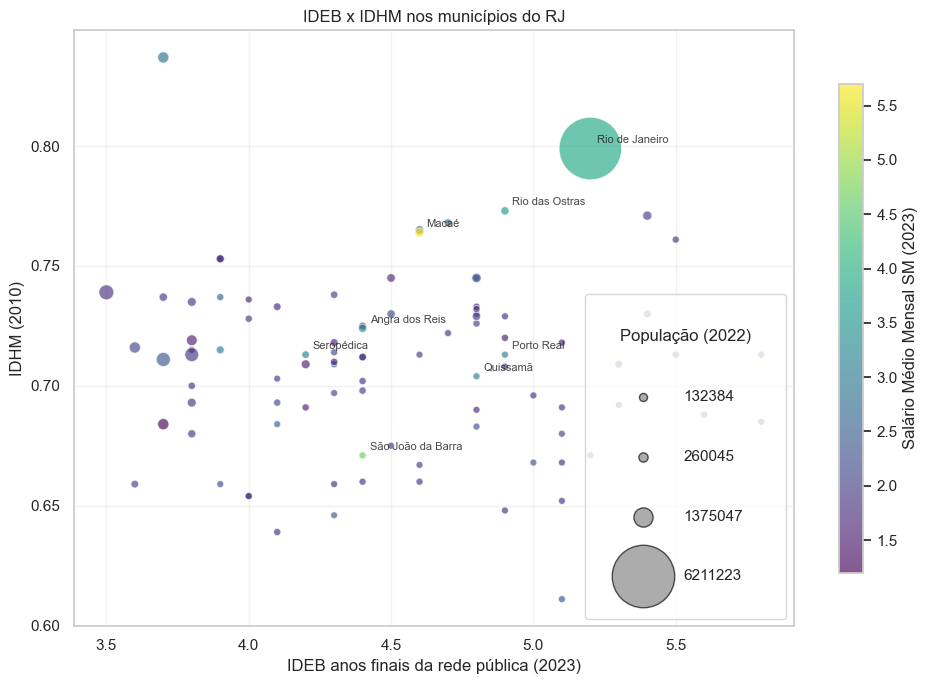

In [54]:
# Gráfico de bolhas: menor para maior bolha
x_col = 'ideb_anos_finais_publica_2023'
y_col = 'idhm_2010'
pop_col = 'pop_2022'
sal_col = 'salario_medio_mensal_sm_2023'

bolhas = (
    gdf[['municipio', x_col, y_col, pop_col, sal_col]]
    .dropna(subset=[x_col, y_col, pop_col])
    .sort_values(pop_col, ascending=True)
    .copy()
)

# Em matplotlib, s representa área; elevamos o raio ao quadrado para que o raio codifique a população.
raio = np.interp(
    bolhas[pop_col],
    (bolhas[pop_col].min(), bolhas[pop_col].max()),
    (5, 45)
)
bolhas['area_bolha'] = raio ** 2

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    bolhas[x_col],
    bolhas[y_col],
    s=bolhas['area_bolha'],
    c=bolhas[sal_col],
    cmap='viridis',
    alpha=0.65,
    edgecolors='white',
    linewidth=0.7
)

for _, row in bolhas.sort_values(by=sal_col).tail(8).iterrows():
    ax.annotate(
        row['municipio'],
        xy=(row[x_col], row[y_col]),
        xytext=(5, 4),
        textcoords='offset points',
        fontsize=8,
        alpha=0.85
    )

# Values you want to show in the legend
legend_values = [gdf['pop_2022'].quantile(0.75), gdf['pop_2022'].quantile(0.9), 
                 gdf['pop_2022'].quantile(0.99), gdf['pop_2022'].max()]
legend_values = [str(int(i)) for i in legend_values]

# Compute the same radius used in the plot
legend_radius = np.interp(
    legend_values,
    (bolhas[pop_col].min(), bolhas[pop_col].max()),
    (5, 45)
)

# Create legend handles
handles = [
    plt.scatter(
        [], [],
        s=r**2,
        facecolor='gray',
        edgecolor='black',
        alpha=0.65
    )
    for r in legend_radius
]

ax.legend(handles, legend_values, title='População (2022)', 
          loc='lower right', frameon=True, labelspacing=3.0,
          borderpad=2.3, handletextpad=1.6)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.82)
cbar.set_label('Salário Médio Mensal SM (2023)')

ax.set_xlabel('IDEB anos finais da rede pública (2023)')
ax.set_ylabel('IDHM (2010)')
ax.set_title('IDEB x IDHM nos municípios do RJ')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 2. Realizar análise exploratória em dados geoespaciais

Em dados geoespaciais, a EDA deve incluir **visualização cartográfica** e a investigação de **autocorrelação espacial** — a tendência de valores semelhantes se agruparem geograficamente.

> Assim, 2 graus de liberdade são destinados para as coordenadas geográficas!

### **2.1 Sintese gráfica com mapas coropléticos**

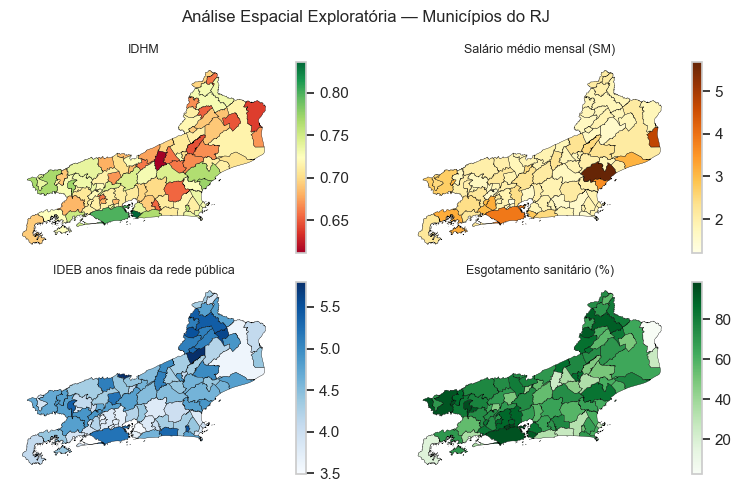

In [55]:
variaveis = [
    ('idhm_2010',                     'IDHM',                         'RdYlGn'),
    ('salario_medio_mensal_sm_2023',  'Salário médio mensal (SM)',     'YlOrBr'),
    ('ideb_anos_finais_publica_2023', 'IDEB anos finais da rede pública',    'Blues'),
    ('esgotamento_sanitario_pct_2022','Esgotamento sanitário (%)',     'Greens'),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for ax, (col, titulo, cmap) in zip(axes.flatten(), variaveis):
    gdf.plot(column=col, ax=ax, legend=True, cmap=cmap,
             edgecolor='black', linewidth=0.25)
    ax.set_title(titulo, fontsize=9)
    ax.set_axis_off()

plt.suptitle('Análise Espacial Exploratória — Municípios do RJ', fontsize=12)
plt.tight_layout()
plt.show()

### **2.2 Extração de atributos Geoespaciais**

Frequentemente, os atributos geoespaciais mais informativas **não estão no dado original**, mas são derivadas da geometria ou da relação espacial entre feições.

| Feature derivada | Como calcular | Exemplo de uso |
|-----------------|---------------|----------------|
| Distância a uma feição | `geometry.distance()` | Distância à capital, ao mar, a rodovias |
| Densidade de vizinhança | Contagem em buffer | Nº de equipamentos no raio de 5 km |
| Comportamento de vizinhança | Média dos vizinhos | "Diga-me quem são seus vizinhos e eu lhe direi quem você é." |
| Área e perímetro | `geometry.area`, `.length` | Compacidade territorial |
| Centroide | `geometry.centroid` | Coordenadas do centro geométrico |

### **2.2 Extração de atributos Geoespaciais**

Média do IDHM e Salário dos 3 vizinhos mais próximos e Distância à capital


In [56]:
from scipy.spatial import cKDTree

# Adição das colunas lat, lon e centroid no objeto gdf
gdf_m = gdf.to_crs('EPSG:3857') # metros
gdf_m['centroid'] = gdf_m.geometry.centroid
gdf_m['lon'] = gdf_m['centroid'].x
gdf_m['lat'] = gdf_m['centroid'].y
coords = gdf_m[['lat','lon']].values

# Pesquisa dos 3 KNN pelo método KDTree
tree = cKDTree(coords)
k = 3
dists, idxs = tree.query(coords, k=k+1)  # k+1 porque o próprio ponto é retornado
vizinhos_idx = idxs[:, 1:]               # Exclui o próprio ponto

# Cálculo da média dos vizinhos no atributo
gdf_m['idhm_viz'] = gdf_m['idhm_2010'].values[vizinhos_idx].mean(axis=1).round(3)
gdf_m['salario_viz'] = gdf['salario_medio_mensal_sm_2023'].values[vizinhos_idx].mean(axis=1).round(2)

# Centroide e distância à capital em um CRS métrico adequado ao RJ.
# gdf_m = gdf.to_crs('EPSG:31983')
centroides_m = gdf_m.geometry.centroid
capital_geom = centroides_m.loc[gdf['municipio'].eq('Rio de Janeiro')].iloc[0]
gdf['dist_capital_km'] = (centroides_m.distance(capital_geom) / 1000).round(1)

gdf_m[['municipio','idhm_2010','idhm_viz','salario_medio_mensal_sm_2023','salario_viz','dist_capital_km']].head(7)

,municipio,idhm_2010,idhm_viz,salario_medio_mensal_sm_2023,salario_viz,dist_capital_km
0,Angra dos Reis,0.724,0.710,3.2,2.27,92.7
1,Aperibé,0.692,0.692,1.8,1.97,195.5
2,Araruama,0.718,0.735,1.6,1.77,120.3
3,Areal,0.684,0.724,2.5,2.00,83.4
4,Armação dos Búzios,0.728,0.727,1.9,1.77,155.0
5,Arraial do Cabo,0.733,0.730,1.5,1.80,132.5
6,Barra do Piraí,0.733,0.741,1.7,1.83,72.7


### **2.3 Correlação espacial pelo Índice de Moran**

O **Índice de Moran ($I$)** mede se valores semelhantes tendem a se agrupar no espaço:

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

Onde $x_i$ é valor observado na localidade i, $x_j$ é valor observado na localidade j e $w_{ij}$ é o peso espacial que mede a relação espacial entre as localidades i e j. 

Uma abordagem comum é definir o peso como inverso da distância entre as localidade i e j $(w_{ij}=1/d_{ij})$. Ou ainda, $w_{ij}=1$ caso as localidades sejam vizinhas e $w_{ij}=0$ caso não vizinhos.

O Índice de Moran geralmente varia aproximadamente entre −1 e 1, onde:

- $I \approx 1$ : forte autocorrelação espacial positiva (valores semelhantes agrupados no espaço);
- $I \approx -1$ : forte autocorrelação espacial negativa (valores distintos tendem a ser vizinhos);
- $I \approx 0$ : ausência de padrão espacial evidente (distribuição aleatória).


### **2.3 Correlação espacial pelo Índice de Moran**

In [57]:
from scipy.spatial.distance import cdist

def moran_global(valores, coords, k=4):
    """
    Calcula o índice de Moran usando matriz de pesos KNN (k vizinhos mais próximos).
    coords: array (n, 2) com [lat, lon]
    """
    mascara = ~pd.isna(valores)
    x = np.array(valores, dtype=float)[mascara]
    coords_validos = np.array(coords, dtype=float)[mascara]
    n = len(x)
    xm = x - x.mean()

    # Distâncias entre todos os pares
    D = cdist(coords_validos, coords_validos)
    np.fill_diagonal(D, np.inf)

    # Matriz de pesos binária KNN
    W = np.zeros((n, n))
    for i in range(n):
        vizinhos = np.argsort(D[i])[:k]
        W[i, vizinhos] = 1
    W = (W + W.T)  # Simetrizar
    W = W / W.sum()  # Normalizar

    num = n * np.sum(W * np.outer(xm, xm))
    den = W.sum() * np.sum(xm**2)
    return num / den

for col in ['idhm_2010', 'salario_medio_mensal_sm_2023', 'esgotamento_sanitario_pct_2022']:
    I = moran_global(gdf[col].values, coords)
    interpretacao = 'maior agrupamento espacial' if I > 0.1 else ('dispersão' if I < -0.1 else 'aleatório')
    print(f"Moran's I ({col}): {I:+.3f}  →  {interpretacao}")



Moran's I (idhm_2010): +0.189  →  maior agrupamento espacial
Moran's I (salario_medio_mensal_sm_2023): +0.086  →  aleatório
Moran's I (esgotamento_sanitario_pct_2022): +0.260  →  maior agrupamento espacial


### **2.3 Correlação espacial pelo Índice de Moran**

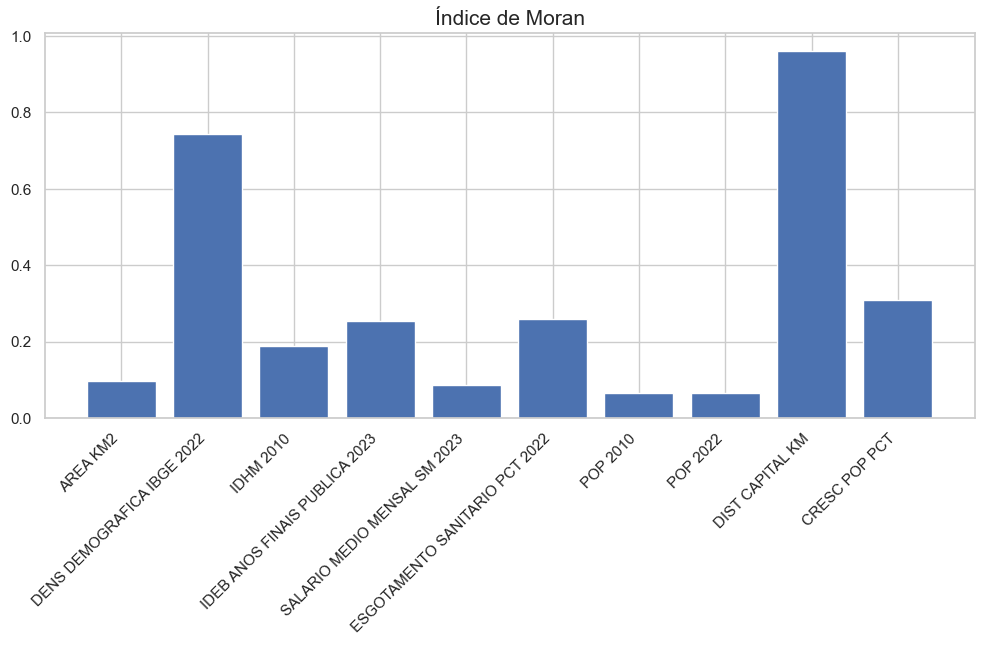

In [58]:
from matplotlib.patches import Patch

Is = {}
for col in num_cols:
    I = moran_global(gdf[col].values, coords)
    Is[col.replace("_", " ").upper()] = I

# Create bar plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(Is.keys(), Is.values())
plt.title("Índice de Moran",fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()


### **2.3 Correlação espacial pelo Índice de Moran**

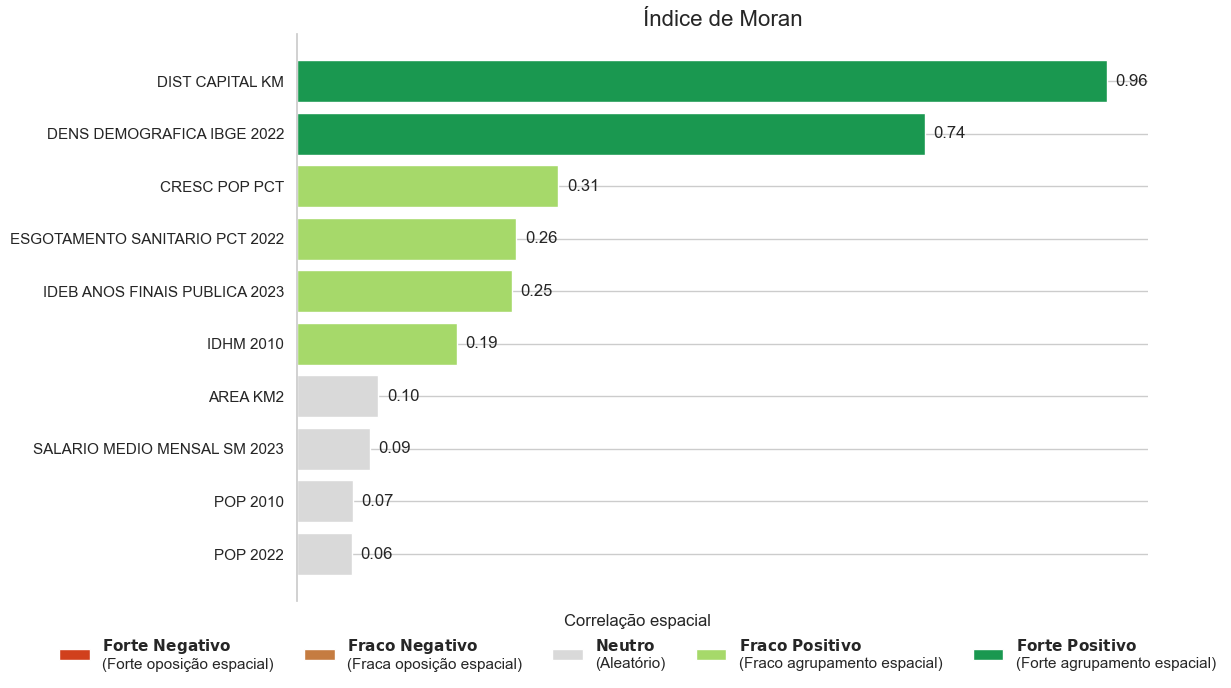

In [59]:
# better bar plot
categories_values = sorted(Is.items(), key=lambda item: item[1])
categories_values = {item[0]:item[1] for item in categories_values}
values = np.array(list(categories_values.values()))
categories = categories_values.keys()

e1 = 0.1
e2 = 0.4
colors = np.where(
    values < -e2, '#2166ac',                    # blue
    np.where(
        values < -e1, '#92c5de',                # light blue
        np.where(
            values <= e1, '#d9d9d9',            # gray
            np.where(
                values <= e2, '#a6d96a',        # light green
                '#1a9850'                       # green
            )
        )
    )
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(categories_values.keys(), categories_values.values(), color=colors)

#
# Remove x-axis
ax.xaxis.set_visible(False)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

legend_elements = [
    Patch(facecolor="#d1401c", label='$\\bf{Forte\\ Negativo}$\n(Forte oposição espacial)'),
    Patch(facecolor="#c57c41", label='$\\bf{Fraco\\ Negativo}$\n(Fraca oposição espacial)'),
    Patch(facecolor='#d9d9d9', label='$\\bf{Neutro }$\n(Aleatório)'),
    Patch(facecolor='#a6d96a', label='$\\bf{Fraco\\ Positivo}$\n(Fraco agrupamento espacial)'),
    Patch(facecolor='#1a9850', label='$\\bf{Forte\\ Positivo}$\n(Forte agrupamento espacial)')
]

ax.legend(
    handles=legend_elements,
    title='Correlação espacial',
    loc='lower center',
    bbox_to_anchor=(0.4, -0.15),
    frameon=False,
    ncol=5
)

plt.title("Índice de Moran",fontsize=16)
plt.tight_layout()
plt.show()

### **2.4 Clusterização - descoberta de grupos nos dados**

<img src="media/imgs/cluster.png">

#### **2.4.1 Agrupamento pelo método das K-médias**

<img src="media/imgs/kmedias.png">

In [60]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Arc
from matplotlib.transforms import Bbox, IdentityTransform, TransformedBbox


class AngleAnnotation(Arc):
    """
    Draws an arc between two vectors which appears circular in display space.
    """
    def __init__(self, xy, p1, p2, size=75, unit="points", ax=None,
                 text="", textposition="inside", text_kw=None, **kwargs):
        """
        Parameters
        ----------
        xy, p1, p2 : tuple or array of two floats
            Center position and two points. Angle annotation is drawn between
            the two vectors connecting *p1* and *p2* with *xy*, respectively.
            Units are data coordinates.

        size : float
            Diameter of the angle annotation in units specified by *unit*.

        unit : str
            One of the following strings to specify the unit of *size*:

            * "pixels": pixels
            * "points": points, use points instead of pixels to not have a
              dependence on the DPI
            * "axes width", "axes height": relative units of Axes width, height
            * "axes min", "axes max": minimum or maximum of relative Axes
              width, height

        ax : `matplotlib.axes.Axes`
            The Axes to add the angle annotation to.

        text : str
            The text to mark the angle with.

        textposition : {"inside", "outside", "edge"}
            Whether to show the text in- or outside the arc. "edge" can be used
            for custom positions anchored at the arc's edge.

        text_kw : dict
            Dictionary of arguments passed to the Annotation.

        **kwargs
            Further parameters are passed to `matplotlib.patches.Arc`. Use this
            to specify, color, linewidth etc. of the arc.

        """
        self.ax = ax or plt.gca()
        self._xydata = xy  # in data coordinates
        self.vec1 = p1
        self.vec2 = p2
        self.size = size
        self.unit = unit
        self.textposition = textposition

        super().__init__(self._xydata, size, size, angle=0.0,
                         theta1=self.theta1, theta2=self.theta2, **kwargs)

        self.set_transform(IdentityTransform())
        self.ax.add_patch(self)

        self.kw = dict(ha="center", va="center",
                       xycoords=IdentityTransform(),
                       xytext=(0, 0), textcoords="offset points",
                       annotation_clip=True)
        self.kw.update(text_kw or {})
        self.text = ax.annotate(text, xy=self._center, **self.kw)

    def get_size(self):
        factor = 1.
        if self.unit == "points":
            factor = self.ax.figure.dpi / 72.
        elif self.unit[:4] == "axes":
            b = TransformedBbox(Bbox.unit(), self.ax.transAxes)
            dic = {"max": max(b.width, b.height),
                   "min": min(b.width, b.height),
                   "width": b.width, "height": b.height}
            factor = dic[self.unit[5:]]
        return self.size * factor

    def set_size(self, size):
        self.size = size

    def get_center_in_pixels(self):
        """return center in pixels"""
        return self.ax.transData.transform(self._xydata)

    def set_center(self, xy):
        """set center in data coordinates"""
        self._xydata = xy

    def get_theta(self, vec):
        vec_in_pixels = self.ax.transData.transform(vec) - self._center
        return np.rad2deg(np.arctan2(vec_in_pixels[1], vec_in_pixels[0]))

    def get_theta1(self):
        return self.get_theta(self.vec1)

    def get_theta2(self):
        return self.get_theta(self.vec2)

    def set_theta(self, angle):
        pass

    # Redefine attributes of the Arc to always give values in pixel space
    _center = property(get_center_in_pixels, set_center)
    theta1 = property(get_theta1, set_theta)
    theta2 = property(get_theta2, set_theta)
    width = property(get_size, set_size)
    height = property(get_size, set_size)

    # The following two methods are needed to update the text position.
    def draw(self, renderer):
        self.update_text()
        super().draw(renderer)

    def update_text(self):
        c = self._center
        s = self.get_size()
        angle_span = (self.theta2 - self.theta1) % 360
        angle = np.deg2rad(self.theta1 + angle_span / 2)
        r = s / 2
        if self.textposition == "inside":
            r = s / np.interp(angle_span, [60, 90, 135, 180],
                                          [3.3, 3.5, 3.8, 4])
        self.text.xy = c + r * np.array([np.cos(angle), np.sin(angle)])
        if self.textposition == "outside":
            def R90(a, r, w, h):
                if a < np.arctan(h/2/(r+w/2)):
                    return np.sqrt((r+w/2)**2 + (np.tan(a)*(r+w/2))**2)
                else:
                    c = np.sqrt((w/2)**2+(h/2)**2)
                    T = np.arcsin(c * np.cos(np.pi/2 - a + np.arcsin(h/2/c))/r)
                    xy = r * np.array([np.cos(a + T), np.sin(a + T)])
                    xy += np.array([w/2, h/2])
                    return np.sqrt(np.sum(xy**2))

            def R(a, r, w, h):
                aa = (a % (np.pi/4))*((a % (np.pi/2)) <= np.pi/4) + \
                     (np.pi/4 - (a % (np.pi/4)))*((a % (np.pi/2)) >= np.pi/4)
                return R90(aa, r, *[w, h][::int(np.sign(np.cos(2*a)))])

            bbox = self.text.get_window_extent()
            X = R(angle, r, bbox.width, bbox.height)
            trans = self.ax.figure.dpi_scale_trans.inverted()
            offs = trans.transform(((X-s/2), 0))[0] * 72
            self.text.set_position([offs*np.cos(angle), offs*np.sin(angle)])

#### **2.4.1 Agrupamento pelo método das K-médias**

Vetor de atributos (X):
 ['idhm_2010', 'salario_medio_mensal_sm_2023', 'ideb_anos_finais_publica_2023', 'esgotamento_sanitario_pct_2022']


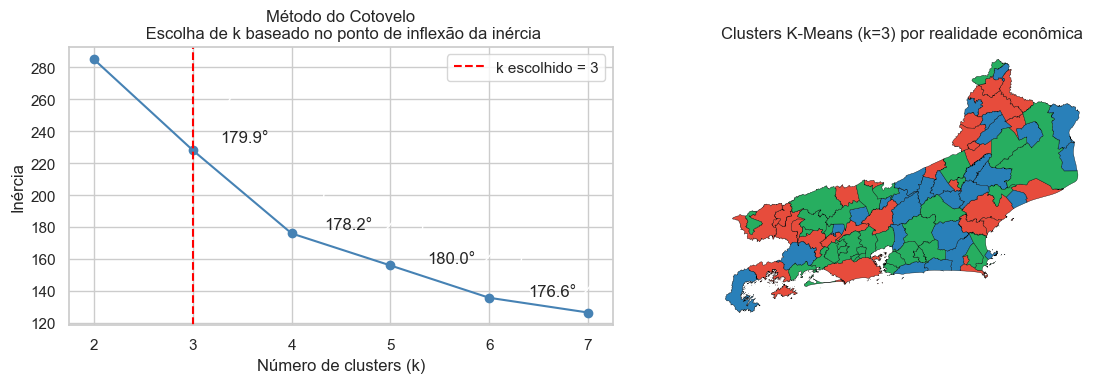

In [75]:
from matplotlib.patches import Arc

def angle_between(v1, v2):
    """Return the angle in degrees between two vectors."""
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    dot_product = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
    return np.degrees(np.arccos(dot_product))
    
#  Features para clusterização
feat_cluster = ['idhm_2010','salario_medio_mensal_sm_2023',
                'ideb_anos_finais_publica_2023','esgotamento_sanitario_pct_2022']
print("Vetor de atributos (X):\n", feat_cluster)
# print(gdf[feat_cluster].head(1).T)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(gdf[feat_cluster])

#  Método do Cotovelo para insight do melhor k
inercias = []
Ks = range(2, 8)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cotovelo
k = 3
axes[0].plot(Ks, inercias, 'o-', color='steelblue')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo\n Escolha de k baseado no ponto de inflexão da inércia')
axes[0].axvline(k, color='red', linestyle='--', label='k escolhido = 3')
axes[0].legend()

for i in range(len(Ks)-2):
    # i = 0 
    p0 = (Ks[i]+0.7, inercias[i]+20)
    p1 = (Ks[i+1]+0.7, inercias[i+1]+20)
    p2 = (Ks[i+2]+0.7, inercias[i+2]+20)

    v1 = np.array(p0) - np.array(p1)
    v2 = np.array(p2) - np.array(p1)

    # Calculate angle
    ang = angle_between(v1, v2)
    AngleAnnotation(p1, p0, p2, ax=axes[0], size=75, text=f"{ang:.1f}°")

# Mapa dos clusters
km_final = KMeans(n_clusters=k, random_state=42, n_init=10)
gdf['cluster_kmeans'] = km_final.fit_predict(X_scaled)

cores_cluster = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
for c, cor in cores_cluster.items():
    subset = gdf[gdf['cluster_kmeans'] == c]
    subset.plot(ax=axes[1], color=cor, edgecolor='black', linewidth=0.25)
axes[1].set_title(f'Clusters K-Means (k={k}) por realidade econômica')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# Perfil de cada cluster
# print("\nPerfil médio por cluster:")
# print(gdf.groupby('cluster_kmeans')[feat_cluster].mean().round(2))

#### **2.4.2 Agrupamento pela densidade DBSCAN**

O Density-Based Spatial Clustering of Applications with Noise (**DBSCAN**):

- **Não requer** $k$ definido a priori
- Detecta clusters de **forma arbitrária**
- Identifica **ruído/outliers** (rótulo `-1`)
- Especialmente adequado para **dados espaciais**

Parâmetros principais:
- `eps`: raio da vizinhança
- `min_samples`: mínimo de pontos para formar um núcleo

#### **2.4.2 Agrupamento pela densidade DBSCAN**

<img src="media/imgs/dbscan.png">

#### **2.4.2 Agrupamento pela densidade DBSCAN**

Vetor de atributos (X):
 ['idhm_2010', 'salario_medio_mensal_sm_2023', 'ideb_anos_finais_publica_2023', 'esgotamento_sanitario_pct_2022']


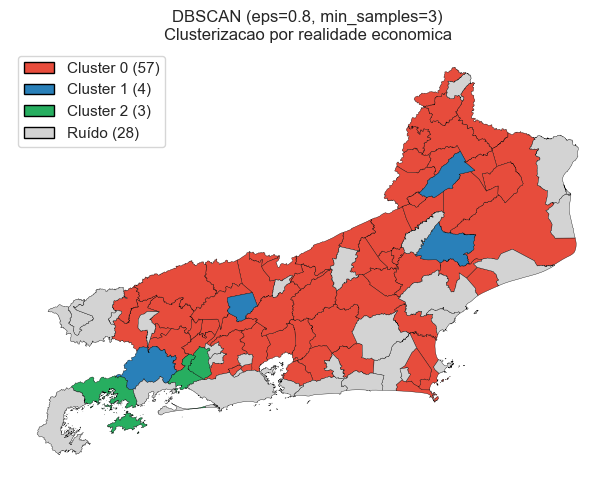

In [84]:
# DBSCAN exaustivo ate encontrar 3 clusters por realidade economica

from matplotlib.patches import Patch

feat_cluster = ['idhm_2010','salario_medio_mensal_sm_2023',
                'ideb_anos_finais_publica_2023','esgotamento_sanitario_pct_2022']
print("Vetor de atributos (X):\n", feat_cluster)

scaler = StandardScaler()
X_economico = scaler.fit_transform(gdf[feat_cluster])

eps_values = np.arange(0.1, 5.01, 0.1)
min_samples_values = range(2, 16)
resultados = []

for eps in eps_values:
    eps = round(float(eps), 2)
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_economico)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = (labels == -1).sum()
        resultados.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_ruido': n_ruido,
            'labels': labels,
        })

resultados_dbscan = pd.DataFrame([
    {k: v for k, v in resultado.items() if k != 'labels'}
    for resultado in resultados
])
candidatos = [resultado for resultado in resultados if resultado['n_clusters'] == 3]

if not candidatos:
    raise ValueError('Nenhuma combinacao de eps/min_samples encontrou exatamente 3 clusters.')

melhor = min(candidatos, key=lambda resultado: (resultado['n_ruido'], resultado['eps'], resultado['min_samples']))

eps = melhor['eps']
min_samples = melhor['min_samples']
gdf['cluster_dbscan_economico'] = melhor['labels']

n_clusters = melhor['n_clusters']
n_ruido = melhor['n_ruido']

fig, ax = plt.subplots(figsize=(7, 5))
legenda = []
cores_cluster = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
for c, cor in cores_cluster.items():
    subset = gdf[gdf['cluster_dbscan_economico'] == c]
    subset.plot(ax=ax, color=cor, edgecolor='black', linewidth=0.25)
    legenda.append(Patch(facecolor=cor, edgecolor='black', label=f'Cluster {c} ({len(subset)})'))

ruido = gdf[gdf['cluster_dbscan_economico'] == -1]
if not ruido.empty:
    ruido.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.25)

ax.set_title(f'DBSCAN (eps={eps}, min_samples={min_samples})\nClusterizacao por realidade economica')
ax.set_axis_off()
if not ruido.empty:
    legenda.append(Patch(facecolor='lightgray', edgecolor='black', label=f'Ruído ({n_ruido})'))
ax.legend(handles=legenda, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 3. Selecionar modelos mais adequados à solução

### **3.1 Classificação - aprendizado de grupos já conhecidos para classificar novos casos**

<img src="media/imgs/class.png">

### **3.1 Classificação - aprendizado de grupos já conhecidos para classificar novos casos**

<img src="media/imgs/classificação.png">

### **3.2 Classificação - exemplos de métodos**

| Método | Ideia central |
|---|---|
| Regressão Logística | Estima a probabilidade de uma classe a partir de uma combinação linear das variáveis. |
| K-Nearest Neighbors (KNN) | Classifica um caso pela classe majoritária dos vizinhos mais próximos no espaço dos atributos. | 
| Árvore de Decisão | Divide os dados por regras sucessivas que maximizam a separação entre classes. | 
| Random Forest | Combina várias árvores treinadas com amostras e variáveis diferentes. | 
| Support Vector Machine (SVM) | Busca a fronteira que maximiza a margem entre classes. | 
| Redes Neurais | Aprende representações não lineares por camadas de pesos ajustáveis. | 

### **3.3 Regressão**

<img src="media/imgs/regressão.png">

### **3.3 Regressão - exemplos de métodos**

| Método | Ideia central |
|---|---|
| Regressão Linear | Modela o alvo como combinação linear dos atributos. |
| KNN Regressor | Prediz pela média dos valores dos vizinhos mais próximos. | 
| Árvore de Regressão | Divide os dados em regiões e prediz a média em cada folha. | 
| Random Forest Regressor | Média de várias árvores de regressão. | 
| Support Vector Regression (SVR) | Ajusta uma função com margem de tolerância para erro. | 
| Redes Neurais | Aprende representações não lineares por camadas de pesos ajustáveis. | 


## Lista de exercícios complementares

**Exercício 1.** Com o dataset desta aula, calcule a correlação de Pearson entre todas as variáveis numéricas e identifique o par com maior e menor correlação. Interprete cada resultado no contexto territorial.

**Exercício 2.** Aplique K-Means com $k \in \{2, 3, 4, 5\}$ usando apenas as coordenadas geográficas (`lat`, `lon`). Compare os mapas resultantes com os clusters obtidos usando variáveis socioeconômicas. Os agrupamentos coincidem? O que isso indica?

**Exercício 3.** Aplique DBSCAN variando `eps` entre 0.5 e 3.0 (passo 0.5). Para cada configuração, registre o número de clusters e de pontos de ruído. Qual configuração você considera mais adequada para o RJ? Justifique.

**Exercício 4.** Treine um `RandomForestRegressor` para prever `cresc_pop_pct` usando apenas variáveis oficiais do IBGE Cidades (`idhm`, `salario_medio_mensal_sm`, `ideb_anos_finais_publica`, `esgotamento_sanitario_pct`). Calcule o MAE e R² por validação cruzada (5-fold). Mapeie os resíduos e calcule o Índice de Moran dos resíduos.

**Exercício 5.** Crie manualmente uma feature de *lag espacial* para a variável `salario_medio_mensal_sm` usando os 5 vizinhos mais próximos. Adicione essa feature ao modelo de regressão e compare o R² antes e depois. A autocorrelação espacial dos resíduos diminuiu?

**Exercício 6 (desafio).** Implemente a **GWR simplificada** (Geographically Weighted Regression): para cada município $i$, treine uma regressão linear ponderada pelos inversos das distâncias aos demais municípios. O alvo é `cresc_pop_pct`. Compare os coeficientes obtidos para `idhm` em municípios da região serrana versus litoral. Os coeficientes são estacionários?